In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Scikit-Learn (Machine Learning utilities)
# -------------------------------
from sklearn.model_selection import train_test_split
#  Splits the dataset into training and testing sets to evaluate model performance.

from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
# LabelEncoder: Converts categorical labels (e.g., "cat", "dog") into numeric values.
# StandardScaler: Normalizes/standardizes numerical features so they have mean=0 and variance=1.

# -------------------------------
# TensorFlow / Keras (Deep Learning utilities)
# -------------------------------
import tensorflow as tf

from tensorflow.keras.models import Sequential
# Lets you build a neural network layer-by-layer in a linear fashion.

from tensorflow.keras.layers import Dense
# Fully connected layer (every neuron connects to every neuron in the next layer).

from tensorflow.keras.layers import Dropout
# Randomly drops some neurons during training to prevent overfitting.


In [3]:
df = pd.read_csv('housing.csv')

In [4]:
df.shape

(20640, 10)

In [5]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [7]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [8]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

In [9]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df['total_bedrooms'] = df['total_bedrooms'].fillna('')

In [12]:
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

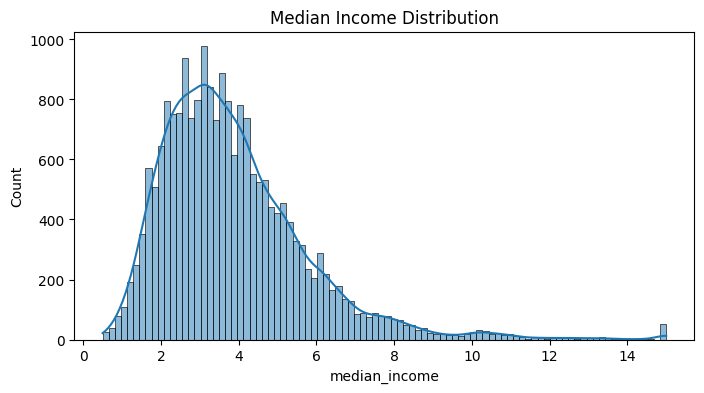

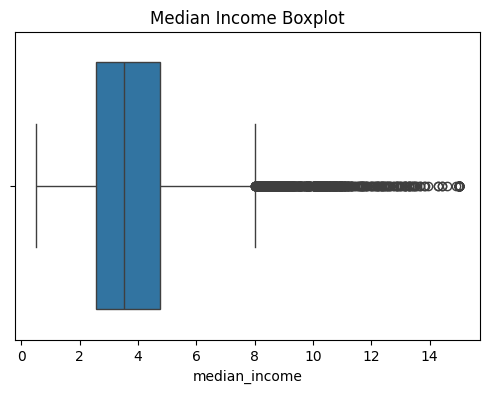

In [14]:
# Histogram
plt.figure(figsize=(8,4))
sns.histplot(df['median_income'], kde=True)
plt.title('Median Income Distribution')
plt.show()

# Box Plot
plt.figure(figsize=(6,4))
sns.boxplot(x=df['median_income'])
plt.title('Median Income Boxplot')
plt.show()

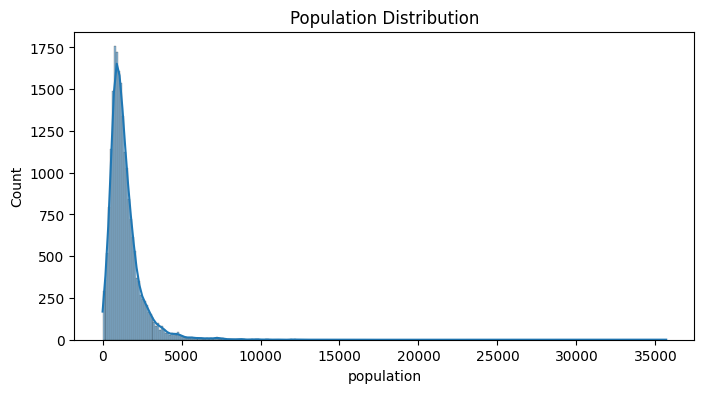

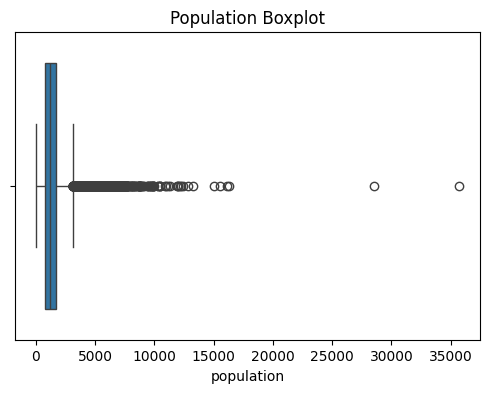

In [15]:
# Histogram
plt.figure(figsize=(8,4))
sns.histplot(df['population'], kde=True)
plt.title('Population Distribution')
plt.show()


# Box Plot

plt.figure(figsize=(6,4))
sns.boxplot(x=df['population'])
plt.title('Population Boxplot')
plt.show()

In [16]:
Q1 = df['population'].quantile(0.25)
Q3 = df['population'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['population'] >= Q1 - 1.5*IQR) & (df['population'] <= Q3 + 1.5*IQR)]

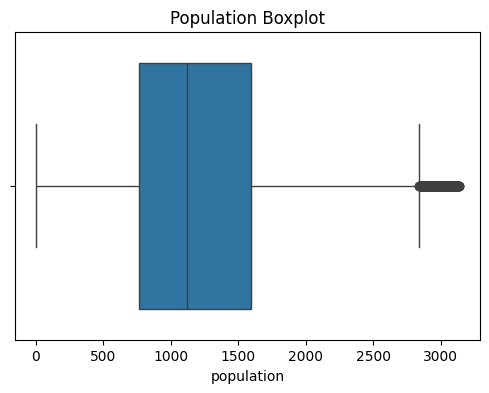

In [17]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['population'])
plt.title('Population Boxplot')
plt.show()

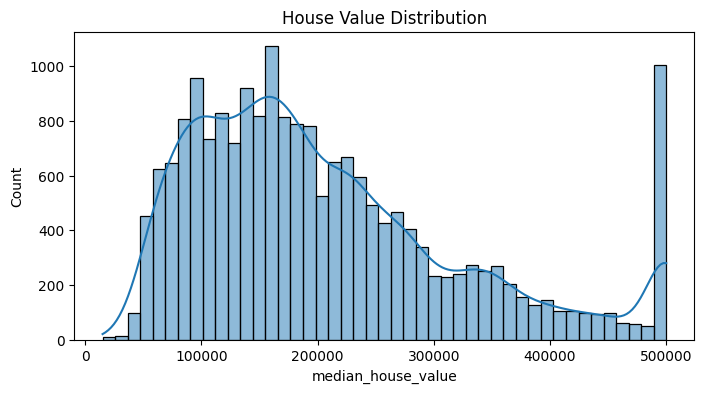

In [18]:
plt.figure(figsize=(8,4))
sns.histplot(df['median_house_value'], kde=True)
plt.title('House Value Distribution')
plt.show()

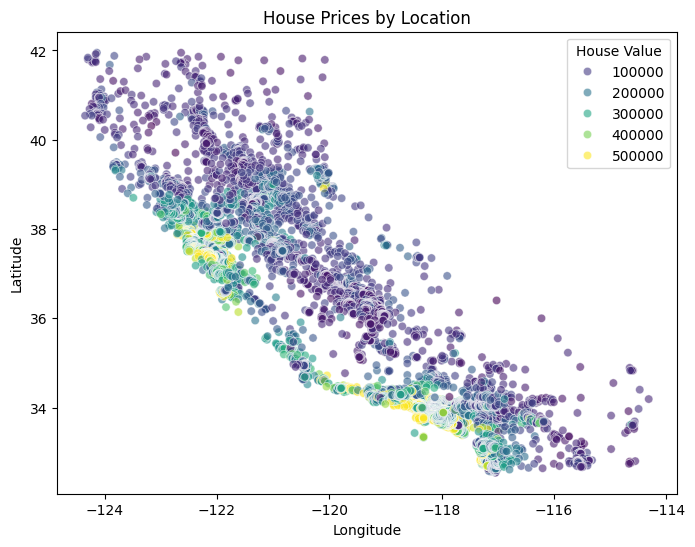

In [19]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['longitude'],
    y=df['latitude'],
    hue=df['median_house_value'],
    palette='viridis',
    alpha=0.6
)

plt.title('House Prices by Location')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='House Value')
plt.show()

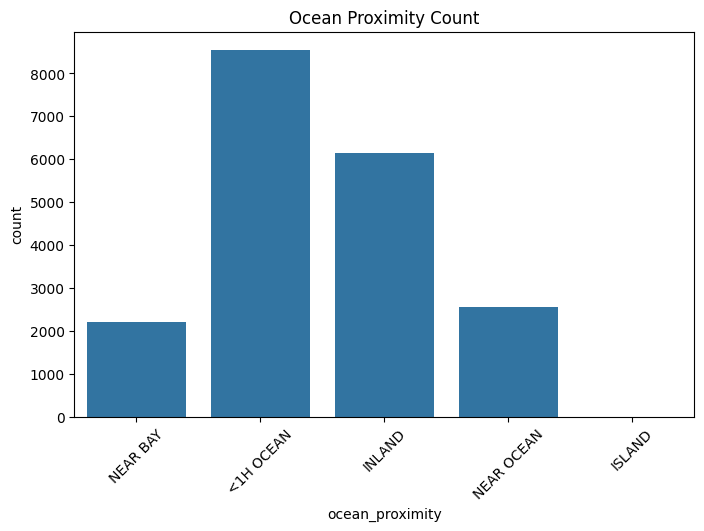

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(x='ocean_proximity', data=df)

plt.title('Ocean Proximity Count')
plt.xticks(rotation=45)
plt.show()

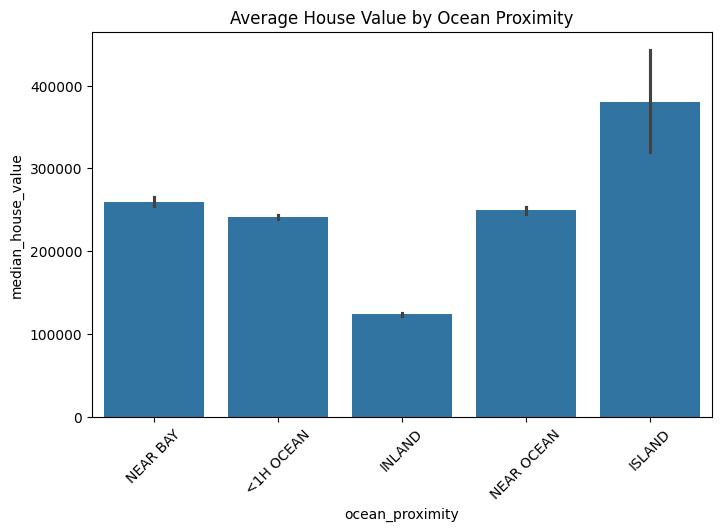

In [21]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='ocean_proximity',
    y='median_house_value',
    data=df
)

plt.title('Average House Value by Ocean Proximity')
plt.xticks(rotation=45)
plt.show()

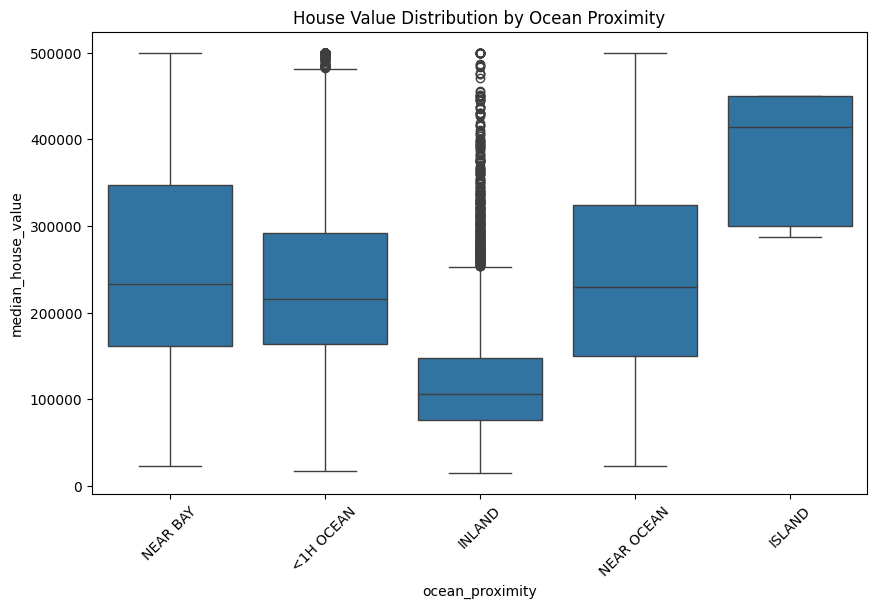

In [22]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='ocean_proximity',
    y='median_house_value',
    data=df
)

plt.title('House Value Distribution by Ocean Proximity')
plt.xticks(rotation=45)
plt.show()

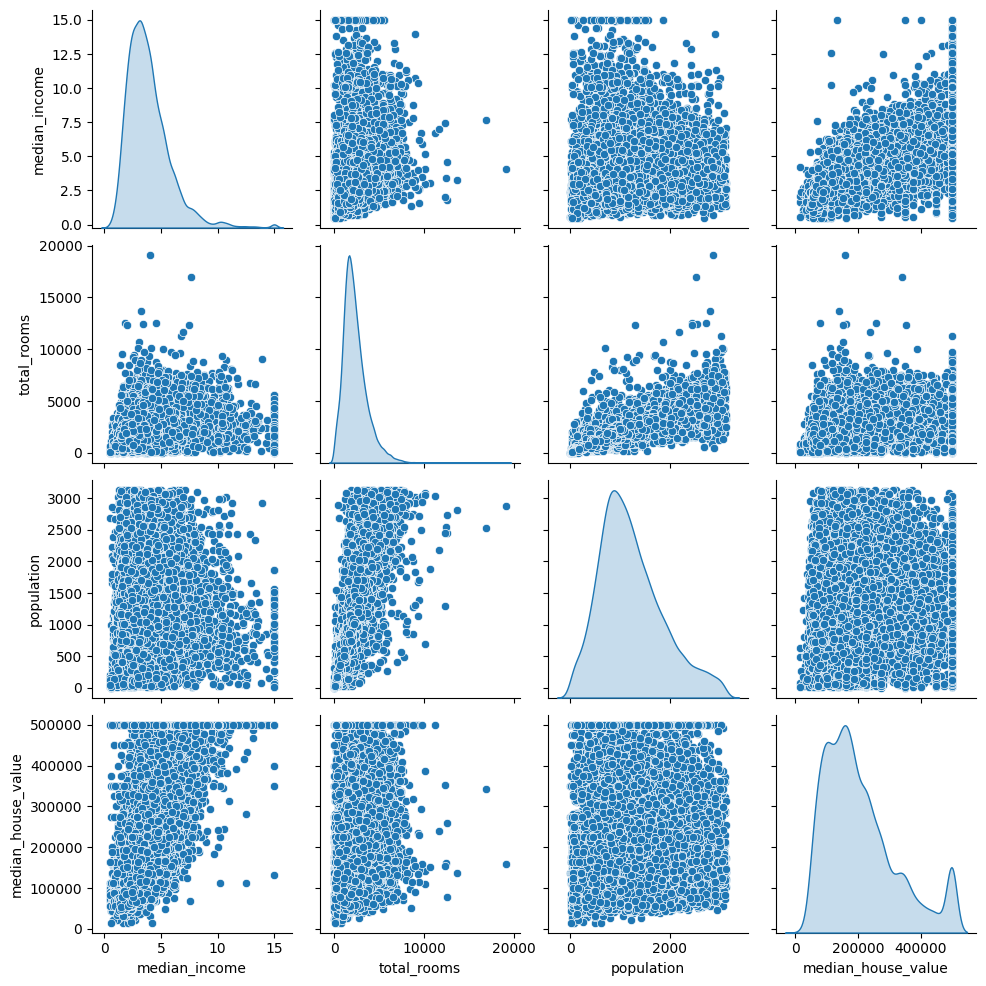

In [23]:
sns.pairplot(
    df[['median_income', 'total_rooms', 'population', 'median_house_value']],
    diag_kind='kde'
)

plt.show()

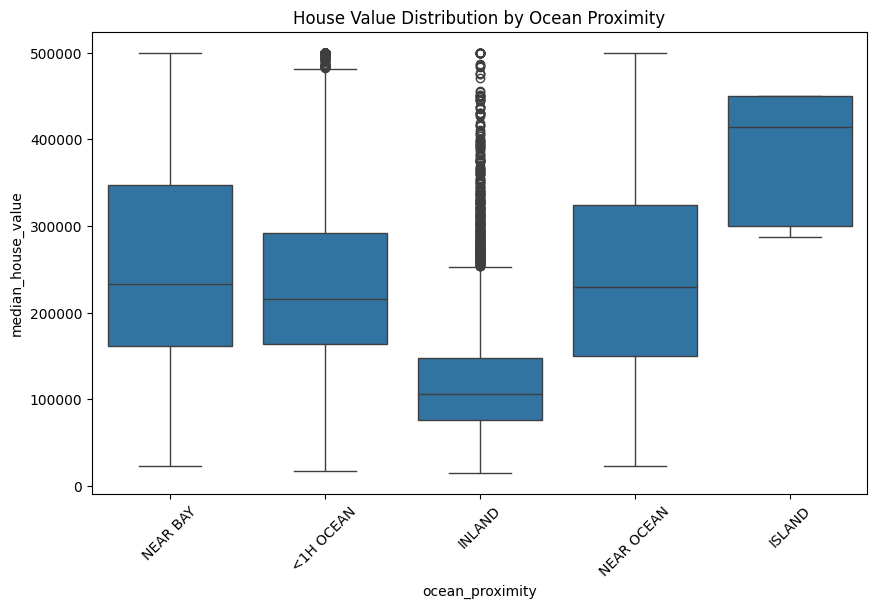

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.boxplot(
    x='ocean_proximity',
    y='median_house_value',
    data=df
)

plt.title('House Value Distribution by Ocean Proximity')
plt.xticks(rotation=45)
plt.show()

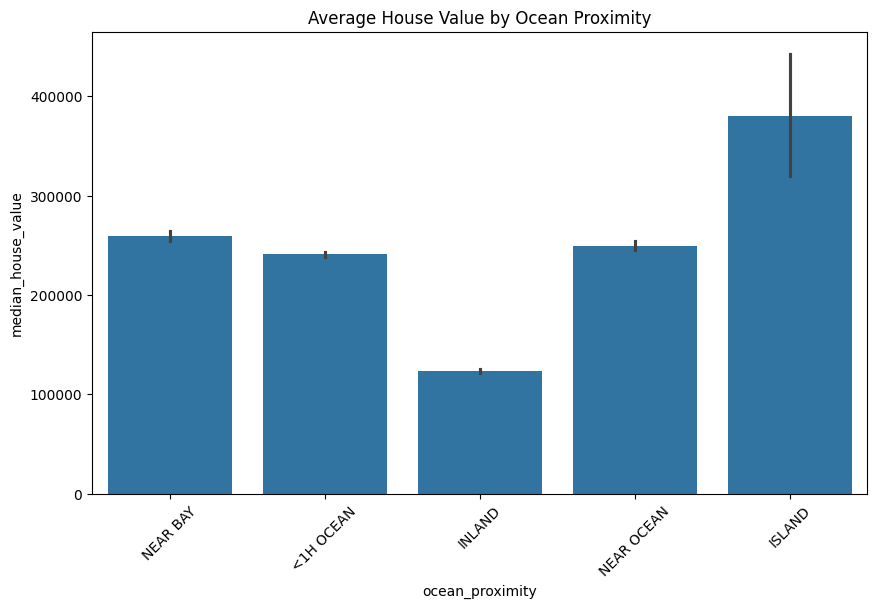

In [25]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='ocean_proximity',
    y='median_house_value',
    data=df
)

plt.title('Average House Value by Ocean Proximity')
plt.xticks(rotation=45)
plt.show()

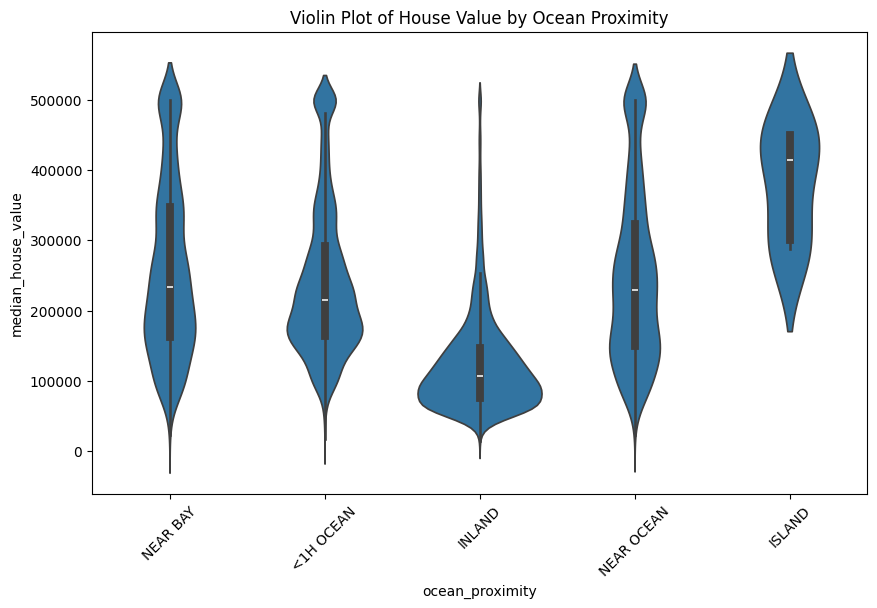

In [26]:
plt.figure(figsize=(10,6))

sns.violinplot(
    x='ocean_proximity',
    y='median_house_value',
    data=df
)

plt.title('Violin Plot of House Value by Ocean Proximity')
plt.xticks(rotation=45)
plt.show()

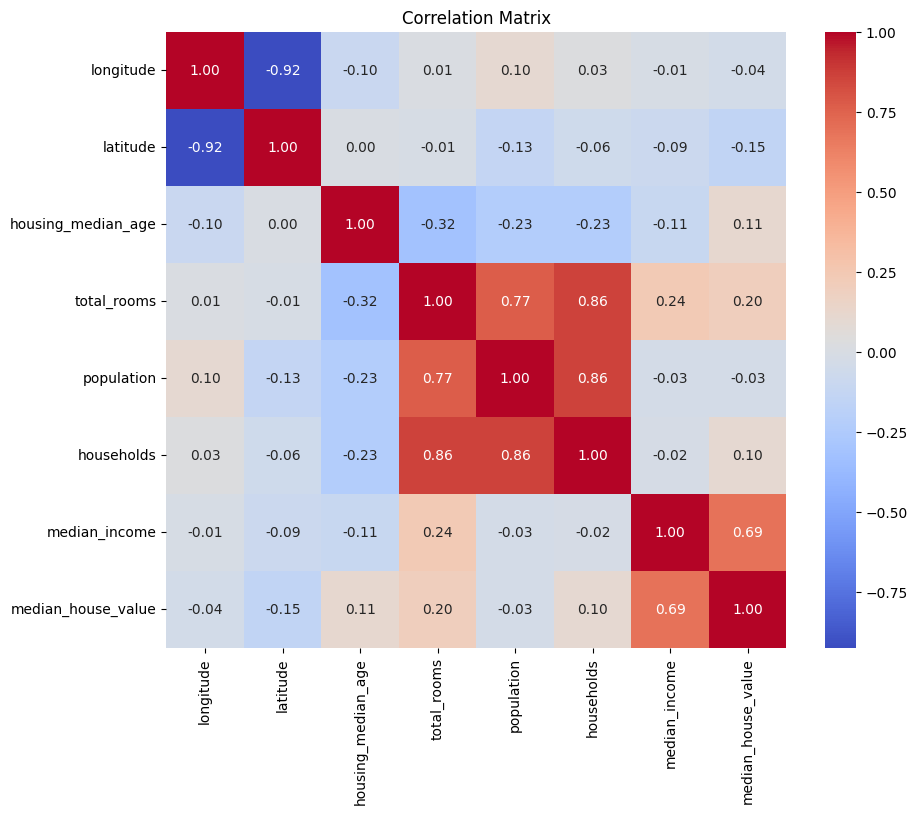

In [27]:
plt.figure(figsize=(10,8))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.show()

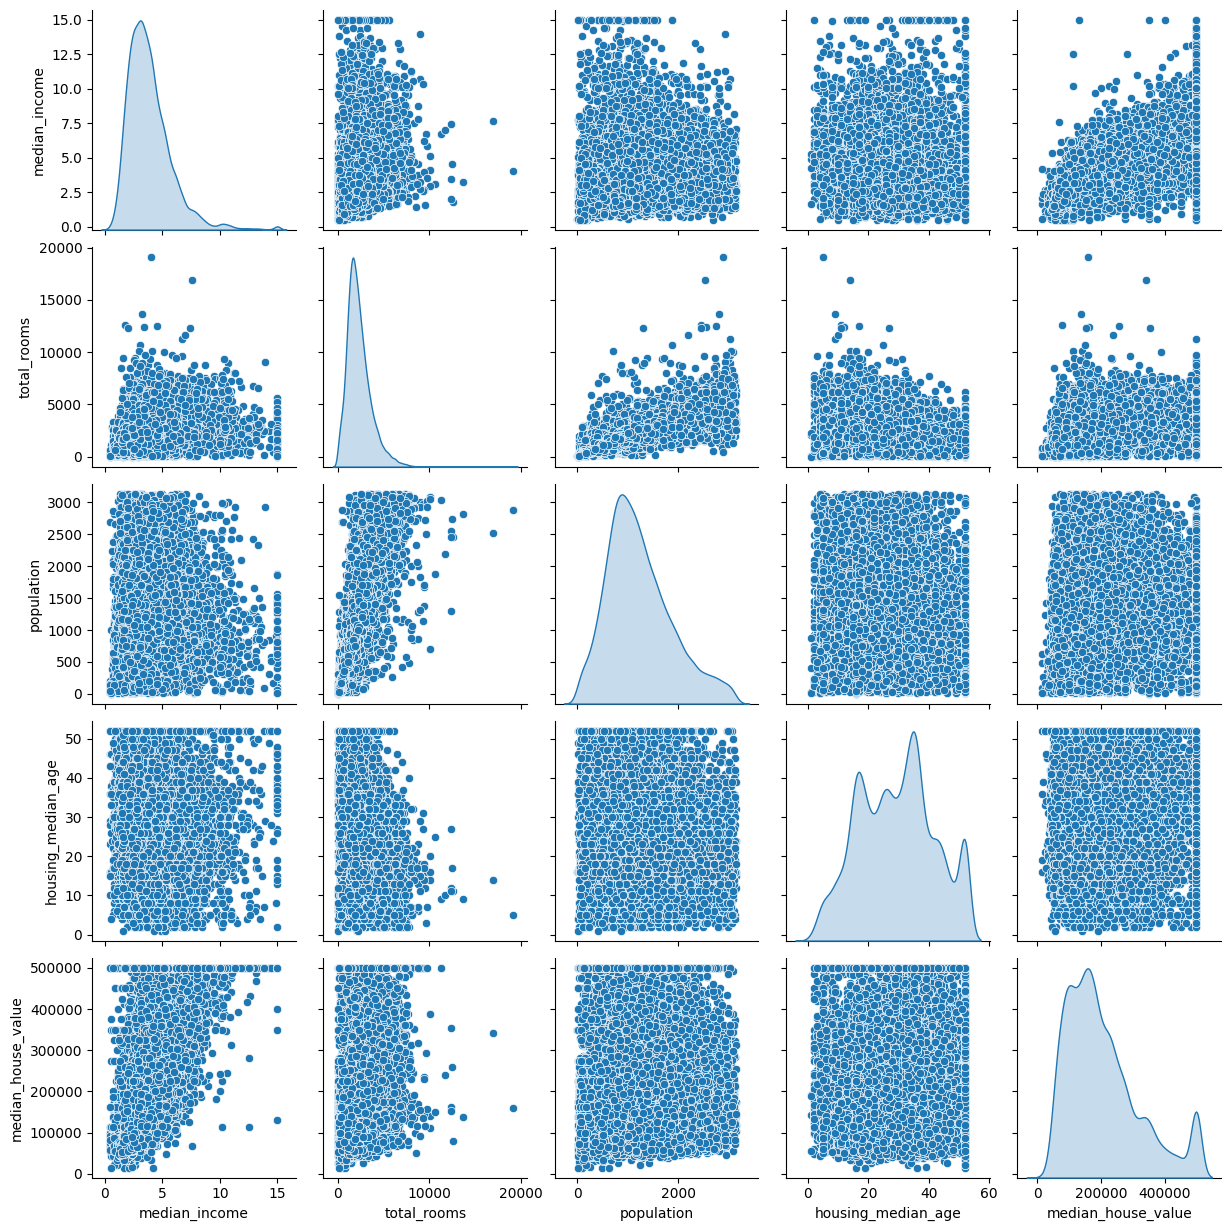

In [28]:
sns.pairplot(
    df[['median_income', 'total_rooms', 'population', 'housing_median_age', 'median_house_value']],
    diag_kind='kde'
)

plt.show()

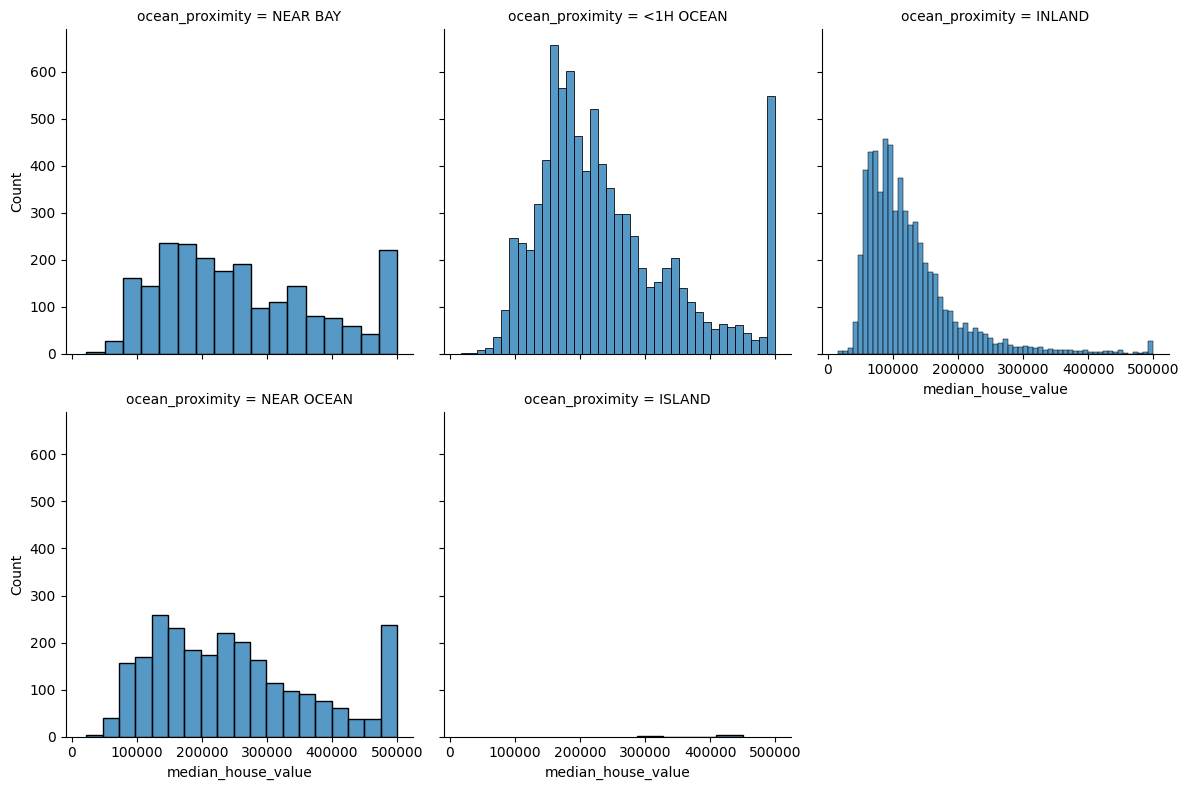

In [29]:
g = sns.FacetGrid(
    df,
    col='ocean_proximity',
    col_wrap=3,
    height=4
)

g.map(sns.histplot, 'median_house_value')

plt.show()

In [30]:
label = LabelEncoder()
df['ocean_proximity'] = label.fit_transform(df['ocean_proximity'])

In [31]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,3
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,3
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,3
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,3
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,3


In [32]:
print(df.dtypes)

longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms         object
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity         int64
dtype: object


In [33]:
df = df.apply(pd.to_numeric, errors='coerce')
df = df.fillna(0)
df = df.round().astype(int)

In [34]:
print(df.dtypes)

longitude             int64
latitude              int64
housing_median_age    int64
total_rooms           int64
total_bedrooms        int64
population            int64
households            int64
median_income         int64
median_house_value    int64
ocean_proximity       int64
dtype: object


In [35]:
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

In [36]:
X.head(2)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
0,-122,38,41,880,129,322,126,8,3
1,-122,38,21,7099,1106,2401,1138,8,3


In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [40]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [41]:
model = Sequential()

# Input Layer + Hidden Layer
model.add(Dense(64, activation='relu', input_dim=X_train.shape[1]))

# Hidden Layer
model.add(Dense(32, activation='relu'))

# Output Layer (Regression)
model.add(Dense(1))

In [42]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [43]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32
)

Epoch 1/50
389/389 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 56642883584.0000 - mae: 207070.9375 - val_loss: 55062159360.0000 - val_mae: 204086.4688
Epoch 2/50
389/389 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 54468386816.0000 - mae: 201813.6875 - val_loss: 50854330368.0000 - val_mae: 193672.9844
Epoch 3/50
389/389 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 47632834560.0000 - mae: 184346.2969 - val_loss: 41654480896.0000 - val_mae: 168670.0000
Epoch 4/50
389/389 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 36553289728.0000 - mae: 152295.7969 - val_loss: 29742692352.0000 - val_mae: 131260.4219
Epoch 5/50
389/389 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 24963469312.0000 - mae: 116475.1016 - val_loss: 19725856768.0000 - val_mae: 101043.3359
Epoch 6/50
389/389 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 17080848384.0000 - mae: 94856.1328 - val_loss: 14569383936.0000 - val_mae: 89165.4219
Epoch 7/50
389/389 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 13839598592.0000 - mae: 88433.4844 - val_loss: 1310976

In [44]:
loss, mae = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test MAE:", mae)

122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 5876450304.0000 - mae: 57558.6680
Test Loss: 5876450304.0
Test MAE: 57558.66796875


In [45]:
y_pred = model.predict(X_test)

122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [46]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [48]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 57558.67578125
MSE: 5876450816.0
R2 Score: 0.5533337593078613


In [49]:
# New features (VERY IMPORTANT)
df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population'] / df['households']

In [50]:
import numpy as np

df['population'] = np.log1p(df['population'])
df['total_rooms'] = np.log1p(df['total_rooms'])
df['total_bedrooms'] = np.log1p(df['total_bedrooms'])
df['households'] = np.log1p(df['households'])

In [51]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

model = Sequential()

model.add(Dense(128, activation='relu', input_dim=X_train.shape[1]))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(32, activation='relu'))

model.add(Dense(1))  # output

In [52]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [53]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [57]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 4370916352.0000 - mae: 47819.9219 - val_loss: 3358991360.0000 - val_mae: 39858.0000
Epoch 2/200
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 4318209024.0000 - mae: 47675.1250 - val_loss: 3318011648.0000 - val_mae: 39858.5078
Epoch 3/200
195/195 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 4370089472.0000 - mae: 48102.4648 - val_loss: 3371151360.0000 - val_mae: 41727.7578
Epoch 4/200
195/195 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 4302943744.0000 - mae: 47497.5977 - val_loss: 3363482880.0000 - val_mae: 41459.6914
Epoch 5/200
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 4301971456.0000 - mae: 47813.1680 - val_loss: 3467922176.0000 - val_mae: 43109.1953
Epoch 6/200
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 4397114880.0000 - mae: 47881.1484 - val_loss: 3337322752.0000 - val_mae: 40264.4336
Epoch 7/200
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 4304376320.0000 - mae: 47467.6016 - val_loss: 3336566016.0000 - val

In [58]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 57558.67578125
MSE: 5876450816.0
R2 Score: 0.5533337593078613


In [59]:
model = Sequential([
    #input layer
    Dense(1000, input_shape=(X_train.shape[1],), activation='relu'),
    Dropout(0.2),
    #two hidden layers
    Dense(500, activation='relu'),
    Dropout(0.2),
    Dense(250, activation='relu'),
    #output layer
    Dense(1,activation='linear') # here 1 shows countinuous value(regression) 
])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 1000)           │        10,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 500)            │       500,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 250)            │       125,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │           251 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 636,001 (2.43 MB)

 Trainable params: 636,001 (2.43 MB)

 Non-trainable params: 0 (0.00 B)

In [60]:
from tensorflow.keras.optimizers import AdamW

In [61]:
optimizer = AdamW(
    learning_rate=0.001,
    weight_decay=1e-4
)

model.compile(
    optimizer=optimizer,
    loss='mse',
    metrics=['mae']
)

In [62]:
# Compile the model and set easlystoping
# model.compile(optimizer='adamw', loss='mse', metrics=['mae'])
es = EarlyStopping(monitor='val_loss',mode='min',patience=50, restore_best_weights=True)

In [65]:
# fit the model (training)
history3 = model.fit(X_train, y_train, validation_data= (X_test, y_test), callbacks=[es], epochs=100, batch_size=50, verbose=1)

Epoch 1/100
312/312 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step - loss: 3617620992.0000 - mae: 42065.7266 - val_loss: 3658177792.0000 - val_mae: 43290.1016
Epoch 2/100
312/312 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - loss: 3604003328.0000 - mae: 42069.7461 - val_loss: 3551837696.0000 - val_mae: 41791.0312
Epoch 3/100
312/312 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - loss: 3617975296.0000 - mae: 42154.6992 - val_loss: 3759047424.0000 - val_mae: 44427.1758
Epoch 4/100
312/312 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - loss: 3624925184.0000 - mae: 42167.0664 - val_loss: 3662154240.0000 - val_mae: 43240.8867
Epoch 5/100
312/312 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - loss: 3565285632.0000 - mae: 41813.1641 - val_loss: 3533475840.0000 - val_mae: 41404.9297
Epoch 6/100
312/312 ━━━━━━━━━━━━━━━━━━━━ 12s 35ms/step - loss: 3590024192.0000 - mae: 41874.4414 - val_loss: 3666068736.0000 - val_mae: 43565.7891
Epoch 7/100
312/312 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - loss: 3628939520.0000 - mae: 42244.5703 - val_loss: 3569325568.0

In [66]:
y_pred = model.predict(X_test)

print("mae :", mean_absolute_error(y_test,y_pred))
print("mse :", mean_squared_error(y_test,y_pred))
print("score :", r2_score(y_test,y_pred))

122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
mae : 39850.7421875
mse : 3299345920.0
score : 0.7492182850837708


In [69]:
model.save('house_price_ann_model.keras')

In [71]:
# import joblib
# joblib.dump(scaler, 'scaler.pkl')


In [79]:
def predict_single(model, scaler, input_data):
    import numpy as np
    input_data = np.array(input_data).reshape(1,-1)
    input_scaled = scaler.transform(input_data)
    prediction = model.prediction(input_scaled)

    print('Prediction House Value : ', prediction[0][0])
    return prediction